In [1]:
# IMPORTS
import stim
print(stim.__version__)

1.15.0


In [2]:
circuit = stim.Circuit()

# First, the circuit will initialize a Bell pair. |01>+|10>
circuit.append("H", [0])
circuit.append("CNOT", [0, 1])
circuit.append("I", [0])
circuit.append("X", [1])

# Then, the circuit will measure both qubits of the Bell pair in the Z basis.
circuit.append("M", [0, 1])

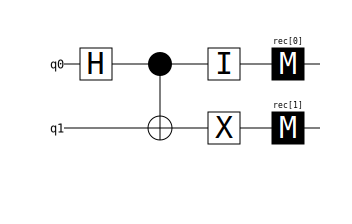

In [3]:
circuit.diagram('timeline-svg')


In [4]:
sampler = circuit.compile_sampler()
print(sampler.sample(shots=10))

[[False  True]
 [ True False]
 [ True False]
 [ True False]
 [False  True]
 [False  True]
 [False  True]
 [ True False]
 [ True False]
 [False  True]]


In [5]:
# Indicate the two previous measurements are supposed to consistently agree.
circuit.append("DETECTOR", [stim.target_rec(-1), stim.target_rec(-2)])
print(repr(circuit))

stim.Circuit('''
    H 0
    CX 0 1
    I 0
    X 1
    M 0 1
    DETECTOR rec[-1] rec[-2]
''')


In [6]:
sampler = circuit.compile_detector_sampler()
print(sampler.sample(shots=5))

[[False]
 [False]
 [False]
 [False]
 [False]]


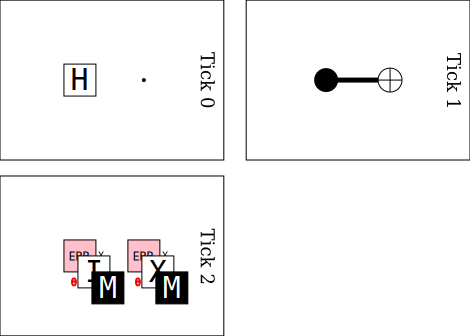

In [7]:
# Adding noise to circuit
circuit = stim.Circuit("""
    H 0
    TICK

    CX 0 1
    TICK

    X_ERROR(0.1) 0 1
    I 0
    X 1
    M 0 1
    DETECTOR rec[-1] rec[-2]
""")
circuit.diagram('timeslice-svg')

In [10]:
sampler = circuit.compile_detector_sampler()
print(sampler.sample(shots=10))

[[False]
 [False]
 [False]
 [False]
 [ True]
 [False]
 [False]
 [False]
 [False]
 [False]]


In [11]:
import numpy as np
print(np.sum(sampler.sample(shots=10**6)) / 10**6)

0.180068


stim.Circuit('''
    R 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16
    TICK
    DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
    CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
    TICK
    CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
    TICK
    X_ERROR(0.01) 1 3 5 7 9 11 13 15
    MR 1 3 5 7 9 11 13 15
    DETECTOR(1, 0) rec[-8]
    DETECTOR(3, 0) rec[-7]
    DETECTOR(5, 0) rec[-6]
    DETECTOR(7, 0) rec[-5]
    DETECTOR(9, 0) rec[-4]
    DETECTOR(11, 0) rec[-3]
    DETECTOR(13, 0) rec[-2]
    DETECTOR(15, 0) rec[-1]
    REPEAT 24 {
        TICK
        DEPOLARIZE1(0.04) 0 2 4 6 8 10 12 14 16
        CX 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
        TICK
        CX 2 1 4 3 6 5 8 7 10 9 12 11 14 13 16 15
        TICK
        X_ERROR(0.01) 1 3 5 7 9 11 13 15
        MR 1 3 5 7 9 11 13 15
        SHIFT_COORDS(0, 1)
        DETECTOR(1, 0) rec[-8] rec[-16]
        DETECTOR(3, 0) rec[-7] rec[-15]
        DETECTOR(5, 0) rec[-6] rec[-14]
        DETECTOR(7, 0) rec[-5] rec[-13]
        DETECTOR(9, 0) rec[-4] r

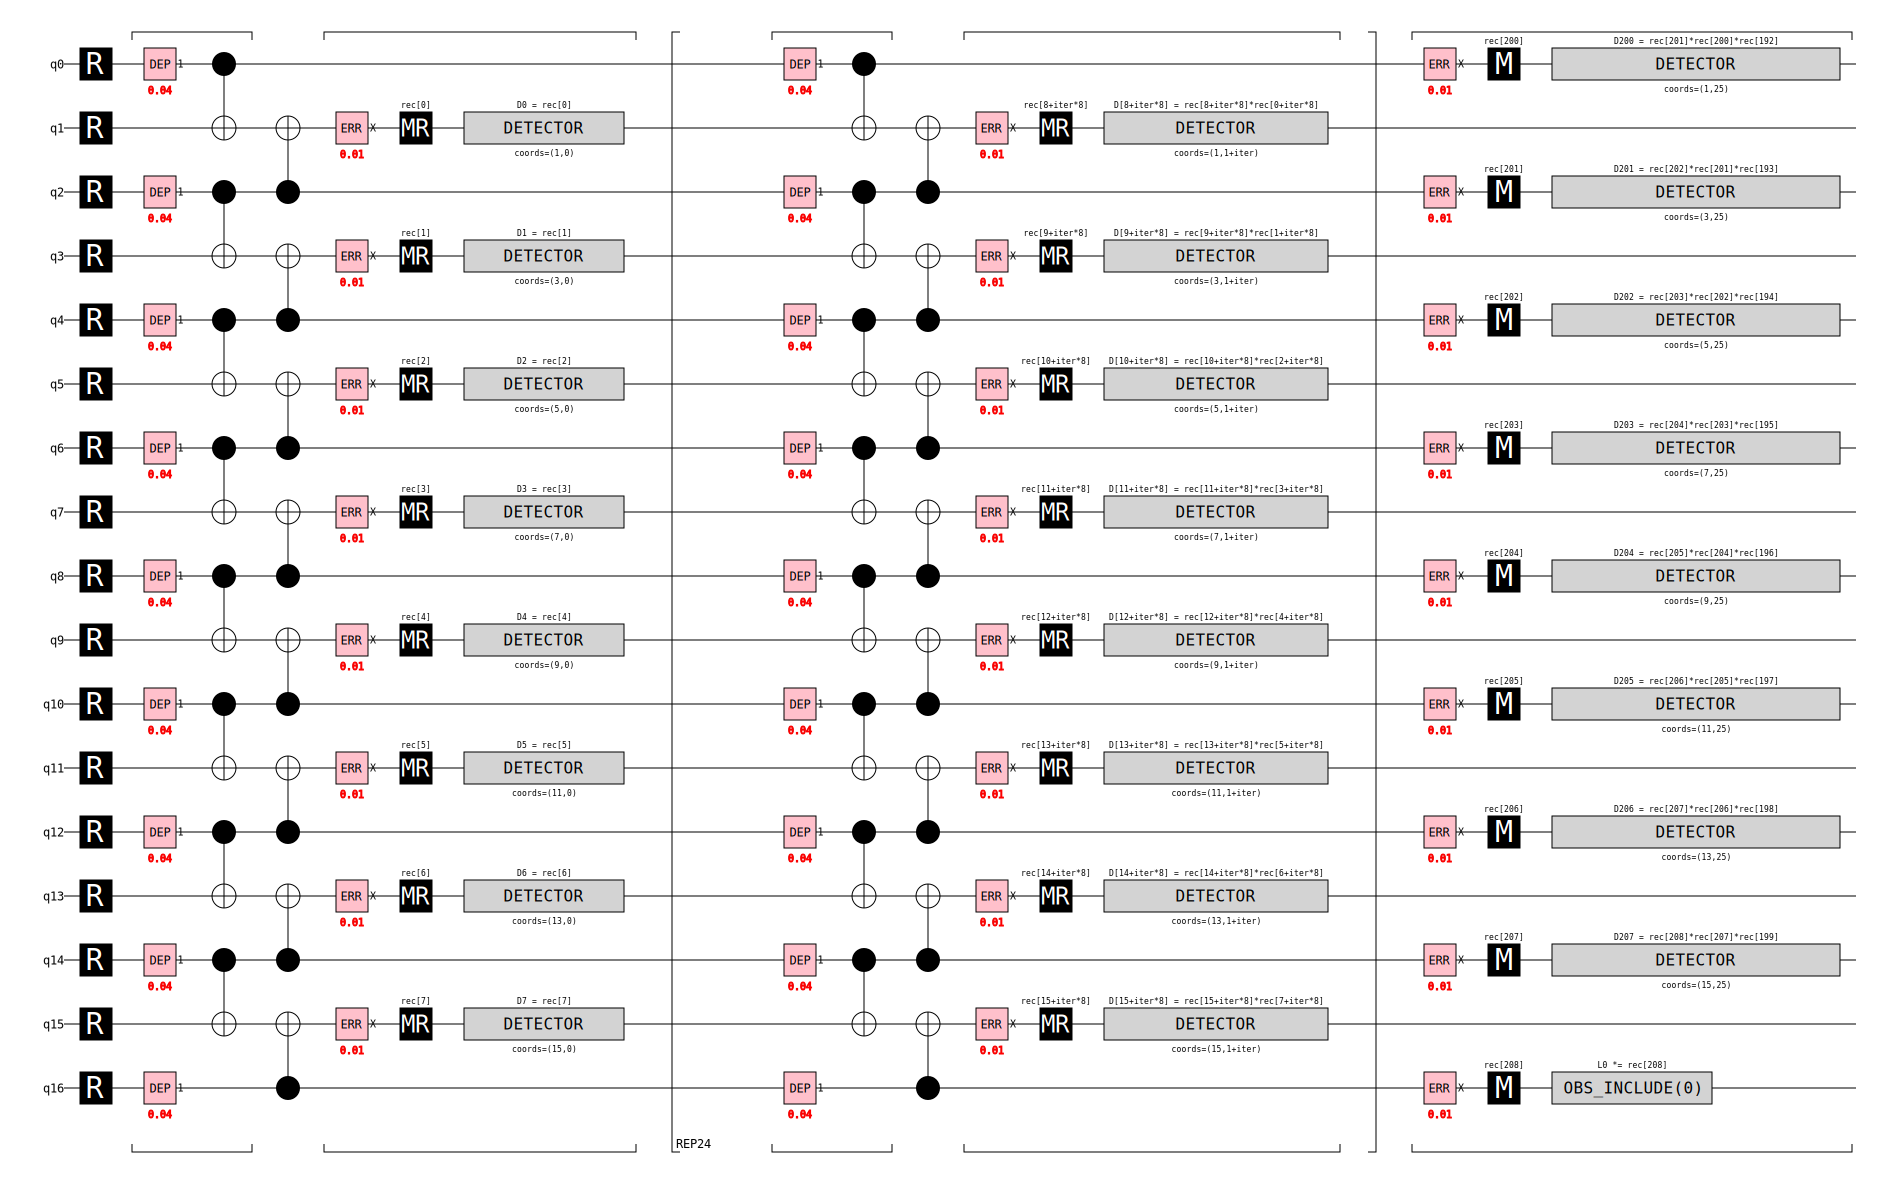

In [12]:
# Repetition Code example

circuit = stim.Circuit.generated(
    "repetition_code:memory",
    rounds=25,
    distance=9,
    before_round_data_depolarization=0.04,
    before_measure_flip_probability=0.01)

print(repr(circuit))
circuit.diagram('timeline-svg')

In [13]:
sampler = circuit.compile_sampler()
one_sample = sampler.sample(shots=1)[0]
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("1" if e else "_" for e in timeslice))

11______
11______
11______
11______
11______
11______
11__11__
11__11__
11__11__
11__11_1
_1__11_1
__1_11_1
__1_11_1
__1_11_1
__1_11_1
__1_11_1
__1_11_1
_1_____1
_1_____1
_1___111
_1___111
_1___111
_1___111
_1___111
___1_111
1111__1_
1


In [14]:
detector_sampler = circuit.compile_detector_sampler()
one_sample = detector_sampler.sample(shots=1)[0]
for k in range(0, len(one_sample), 8):
    timeslice = one_sample[k:k+8]
    print("".join("!" if e else "_" for e in timeslice))



________
________
________
____!!__
________
________
________
________
________
________
________
________
________
________
________
________
________
________
________
________
________
________
_____!!_
________
________
________
